# Progression Rate

> **Prerequisite:** Run `clean_data.ipynb` first. This notebook reads from `cleaned_data/mm_nopgs.csv`.

Summarises the proportion of MGUS patients who progressed to multiple myeloma and plots the Kaplan–Meier survival curve.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lifelines import KaplanMeierFitter

In [2]:
data_path = Path('cleaned_data/mm_nopgs.csv')
assert data_path.exists(), 'cleaned_data/mm_nopgs.csv not found — run clean_data.ipynb first.'

df = pd.read_csv(data_path, index_col='ID')
print(f'Loaded {len(df)} rows')
df.head()

Loaded 2000 rows


,ancestry,age,m_spike,sflc_ratio,creatinine,status,time_years
ID,,,,,,,
1,1,0.137747,2.422286,-0.287442,-1.718453,1,1.335000
2,1,0.652230,2.640049,-0.247821,0.424321,1,0.066667
3,1,-0.033230,-0.725654,-0.319304,-0.646363,0,8.948333
4,1,0.498547,0.015844,0.057345,0.067536,1,4.296667
5,1,-0.346698,1.190935,-0.568467,0.213709,0,3.765000


## Progression summary

In [3]:
n_total      = len(df)
n_progressed = df['status'].sum()
n_censored   = n_total - n_progressed
pct          = 100 * n_progressed / n_total

print(f'Total patients:       {n_total}')
print(f'Progressed to MM:     {n_progressed}  ({pct:.1f}%)')
print(f'Censored (no event):  {n_censored}  ({100-pct:.1f}%)')
print()
print(f'Median follow-up:     {df["time_years"].median():.2f} years')
print(f'Max follow-up:        {df["time_years"].max():.2f} years')

pd.DataFrame({
    'Group':   ['Progressed', 'Censored', 'Total'],
    'N':       [n_progressed, n_censored, n_total],
    '%':       [f'{pct:.1f}', f'{100-pct:.1f}', '100.0'],
})

Total patients:       2000
Progressed to MM:     519  (25.9%)
Censored (no event):  1481  (74.0%)

Median follow-up:     4.95 years
Max follow-up:        10.00 years


,Group,N,%
0,Progressed,519,25.9
1,Censored,1481,74.0
2,Total,2000,100.0


## Kaplan–Meier curve

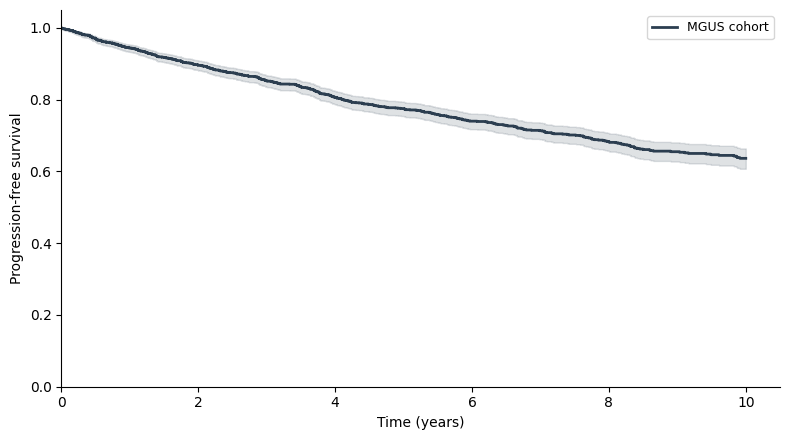

In [4]:
kmf = KaplanMeierFitter()
kmf.fit(df['time_years'], event_observed=df['status'], label='MGUS cohort')

COLOR = '#2c3e50'
CI_COLOR = '#2c3e50'

fig, ax = plt.subplots(figsize=(8, 4.5))

kmf.plot_survival_function(
    ax=ax,
    ci_show=True,
    color=COLOR,
    ci_alpha=0.15,
    linewidth=2,
)

# Annotate median survival time if reached
median_t = kmf.median_survival_time_
if np.isfinite(median_t):
    ax.axvline(median_t, color='black', linewidth=1, linestyle=':', alpha=0.7)
    ax.axhline(0.5,      color='black', linewidth=1, linestyle=':', alpha=0.7)
    ax.text(median_t + 0.1, 0.52, f'Median: {median_t:.1f} yr', fontsize=9)

ax.set_xlabel('Time (years)', fontsize=10)
ax.set_ylabel('Progression-free survival', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_xlim(left=0)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()